# Tutorial 3: Fitting the Top Quark Mass with in-situ JES calibration

In this tutorial we extract the top quark mass from the invariant mass distribution of the 3-jet combination (reconstructed top) while simultaneously fitting the Jet Energy Scale (JES) using the 2-jet combination (reconstructed W).

We use a 2D template approach ($m_W$ vs $m_t$) to capture the correlation between the two observables. The JES acts as a constrained shape systematic that shifts both $m_W$ and $m_t$. The top mass shift acts as an unconstrained parameter affecting only $m_t$.

## Setting up the environment

In [1]:
import os
import sys
from pathlib import Path

# 1. Emulate RABBIT_BASE (points to the 'rabbit' root)
# Since we are in rabbit/notebooks/, we go up one level
rabbit_base = str(Path(os.getcwd()).parent.absolute())
os.environ['RABBIT_BASE'] = rabbit_base

# 2. Update PYTHONPATH so you can 'import rabbit'
if rabbit_base not in sys.path:
    sys.path.append(rabbit_base)
# 2.1 PYTHONPATH also needs to be set to run bash scripts starting with "!"
pythonpath = os.environ.get('PYTHONPATH', '')
if rabbit_base not in pythonpath:
    os.environ['PYTHONPATH'] = rabbit_base + os.pathsep + pythonpath if pythonpath else rabbit_base
    
# 3. Update PATH so you can run scripts from rabbit/bin/
bin_path = os.path.join(rabbit_base, 'bin')
if bin_path not in os.environ['PATH']:
    os.environ['PATH'] = bin_path + os.pathsep + os.environ['PATH']
    
print(f"RABBIT_BASE: {os.environ['RABBIT_BASE']}")
print(f"PATH: {os.environ['PATH']}")

RABBIT_BASE: /home/mseidel/Tools/rabbit
PATH: /home/mseidel/Tools/rabbit/bin:/home/mseidel/Tools/rabbit/env/bin:/usr/local/texlive/2022/bin/x86_64-linux:/home/mseidel/.local/bin:/home/mseidel/Tools/miniconda3/bin:/usr/local/bin:/usr/local/sbin:/usr/bin:/usr/sbin


The following is needed to visualize the plots within this session

In [2]:
from IPython.display import Image, display, IFrame, HTML

## Generating the invariant mass distribution (2D: $m_W$ vs $m_t$)

We will generate an invariant mass distribution representing the reconstructed W and top masses. 
We use pseudo-data and generate a signal peak on top of a background.

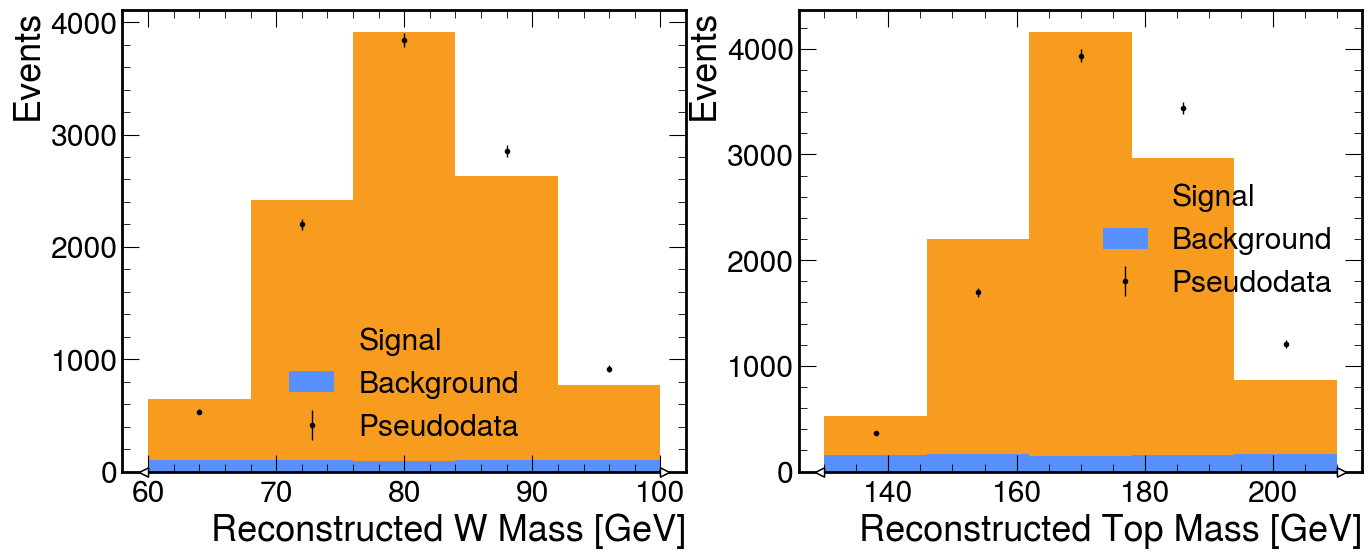

In [3]:
import numpy as np
import hist
import matplotlib.pyplot as plt
import mplhep as hep
from rabbit import tensorwriter
hep.style.use("CMS")

outdir = "results/top_mass"
os.makedirs(outdir, exist_ok=True)

np.random.seed(42)

# Base parameters
n_sig = 10000
n_bkg = 1000
mc_normfactor = 10
m_w_nom = 80.4
m_top_nom = 172.5
dm_top = 3.0
jes_nom = 1.0
djes = 0.02
w_res, top_res = 8.0, 15.0

# 1. Generate INDEPENDENT base arrays for the different MC mass samples
# Nominal Sample
w_mass_nom = np.random.normal(m_w_nom, w_res, n_sig * mc_normfactor)
top_mass_nom = np.random.normal(m_top_nom, top_res, n_sig * mc_normfactor)

# Top Mass Up Sample (Independent seed/events)
w_mass_mtop_up = np.random.normal(m_w_nom, w_res, n_sig * mc_normfactor)
top_mass_mtop_up = np.random.normal(m_top_nom + dm_top, top_res, n_sig * mc_normfactor)

# Top Mass Down Sample (Independent seed/events)
w_mass_mtop_dn = np.random.normal(m_w_nom, w_res, n_sig * mc_normfactor)
top_mass_mtop_dn = np.random.normal(m_top_nom - dm_top, top_res, n_sig * mc_normfactor)

# 2. Map the variations
sig_vars = {
    "nom":     (w_mass_nom, top_mass_nom),
    
    # Theory systematics: Independent arrays
    "mtop_up": (w_mass_mtop_up, top_mass_mtop_up), 
    "mtop_dn": (w_mass_mtop_dn, top_mass_mtop_dn), 
    
    # Experimental systematics: Correlated to nominal arrays
    "jes_up":  (w_mass_nom * (1 + djes), top_mass_nom * (1 + djes)), 
    "jes_dn":  (w_mass_nom * (1 - djes), top_mass_nom * (1 - djes))  
}

# 3. Fill a categorical histogram
syst_axis = hist.axis.StrCategory([], name="syst", growth=True)
w_mass_axis = hist.axis.Regular(5, 60, 100, name="m_W", label="Reconstructed W Mass [GeV]")
top_mass_axis = hist.axis.Regular(5, 130, 210, name="m_top", label="Reconstructed Top Mass [GeV]")
h_sig = hist.Hist(syst_axis, w_mass_axis, top_mass_axis, storage=hist.storage.Weight())

for syst_name, (w, t) in sig_vars.items():
    h_sig.fill(syst=syst_name, m_W=w, m_top=t)

h_sig *= 1.0 / mc_normfactor

# Slice out 2D histograms
h_sig_nom = h_sig["nom", ...]
h_sig_mtop_up = h_sig["mtop_up", ...]
h_sig_mtop_dn = h_sig["mtop_dn", ...]
h_sig_jes_up = h_sig["jes_up", ...]
h_sig_jes_dn = h_sig["jes_dn", ...]

# Background distributions
bkg_w_mass = np.random.uniform(40, 120, n_bkg * mc_normfactor)
bkg_top_mass = np.random.uniform(120, 220, n_bkg * mc_normfactor)

bkg_vars = {
    "nom":     (bkg_w_mass, bkg_top_mass),

    # Experimental systematics: Correlated to nominal arrays
    "jes_up":  (bkg_w_mass * (1 + djes), bkg_top_mass * (1 + djes)), 
    "jes_dn":  (bkg_w_mass * (1 - djes), bkg_top_mass * (1 - djes))  
}

h_bkg = hist.Hist(syst_axis, w_mass_axis, top_mass_axis, storage=hist.storage.Weight())

for syst_name, (w, t) in bkg_vars.items():
    h_bkg.fill(syst=syst_name, m_W=w, m_top=t)

h_bkg *= 1.0 / mc_normfactor

# Slice out 2D histograms
h_bkg_nom = h_bkg["nom", ...]
h_bkg_jes_up = h_bkg["jes_up", ...]
h_bkg_jes_dn = h_bkg["jes_dn", ...]

# Parameters for "true" pseudodata
m_top_true = 174. 
jes_true = 1.01 

# True signal
w_mass_true = np.random.normal(m_w_nom, w_res, n_sig) * jes_true
top_mass_true = np.random.normal(m_top_true, top_res, n_sig) * jes_true

# True background
bkg_w_mass_true = np.random.uniform(40, 120, n_bkg) * jes_true
bkg_top_mass_true = np.random.uniform(120, 220, n_bkg) * jes_true

h_data = hist.Hist(w_mass_axis, top_mass_axis, storage=hist.storage.Weight())
h_data.fill(np.concatenate([w_mass_true, bkg_w_mass_true]), 
            np.concatenate([top_mass_true, bkg_top_mass_true]))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
hep.histplot([h_bkg_nom.project("m_W"), h_sig_nom.project("m_W")], stack=True, histtype='fill', label=['Background', 'Signal'], ax=ax1)
hep.histplot(h_data.project("m_W"), histtype='errorbar', color='black', label='Pseudodata', ax=ax1)
ax1.set_xlabel("Reconstructed W Mass [GeV]")
ax1.set_ylabel("Events")
ax1.legend()

hep.histplot([h_bkg_nom.project("m_top"), h_sig_nom.project("m_top")], stack=True, histtype='fill', label=['Background', 'Signal'], ax=ax2)
hep.histplot(h_data.project("m_top"), histtype='errorbar', color='black', label='Pseudodata', ax=ax2)
ax2.set_xlabel("Reconstructed Top Mass [GeV]")
ax2.set_ylabel("Events")
ax2.legend()
plt.show()

## Plot the mass variations

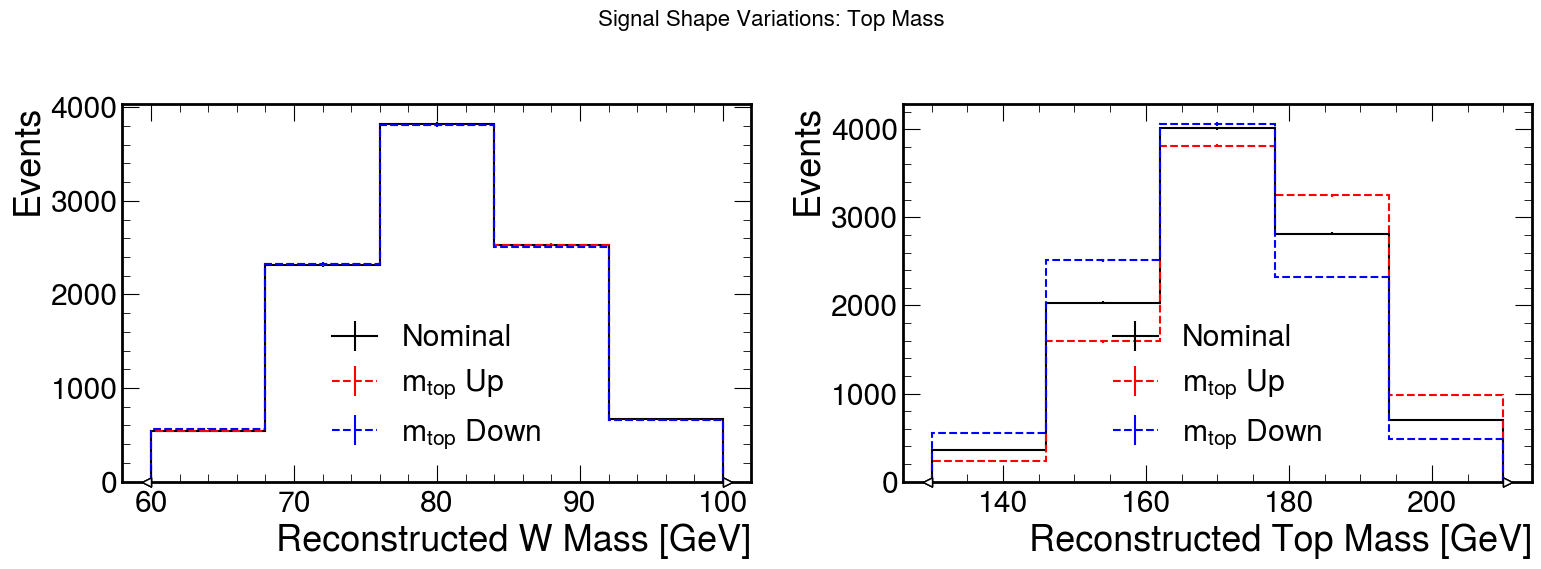

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Signal Shape Variations: Top Mass", fontsize=16)

# Reconstructed W Mass Axis
hep.histplot(h_sig_nom.project("m_W"), color='black', label='Nominal', ax=ax1)
hep.histplot(h_sig_mtop_up.project("m_W"), color='red', linestyle='--', label=r'$m_{top}$ Up', ax=ax1)
hep.histplot(h_sig_mtop_dn.project("m_W"), color='blue', linestyle='--', label=r'$m_{top}$ Down', ax=ax1)
ax1.set_xlabel("Reconstructed W Mass [GeV]")
ax1.set_ylabel("Events")
ax1.legend()

# Reconstructed Top Mass Axis
hep.histplot(h_sig_nom.project("m_top"), color='black', label='Nominal', ax=ax2)
hep.histplot(h_sig_mtop_up.project("m_top"), color='red', linestyle='--', label=r'$m_{top}$ Up', ax=ax2)
hep.histplot(h_sig_mtop_dn.project("m_top"), color='blue', linestyle='--', label=r'$m_{top}$ Down', ax=ax2)
ax2.set_xlabel("Reconstructed Top Mass [GeV]")
ax2.set_ylabel("Events")
ax2.legend()

plt.tight_layout()
plt.show()

## Plot the JES variations

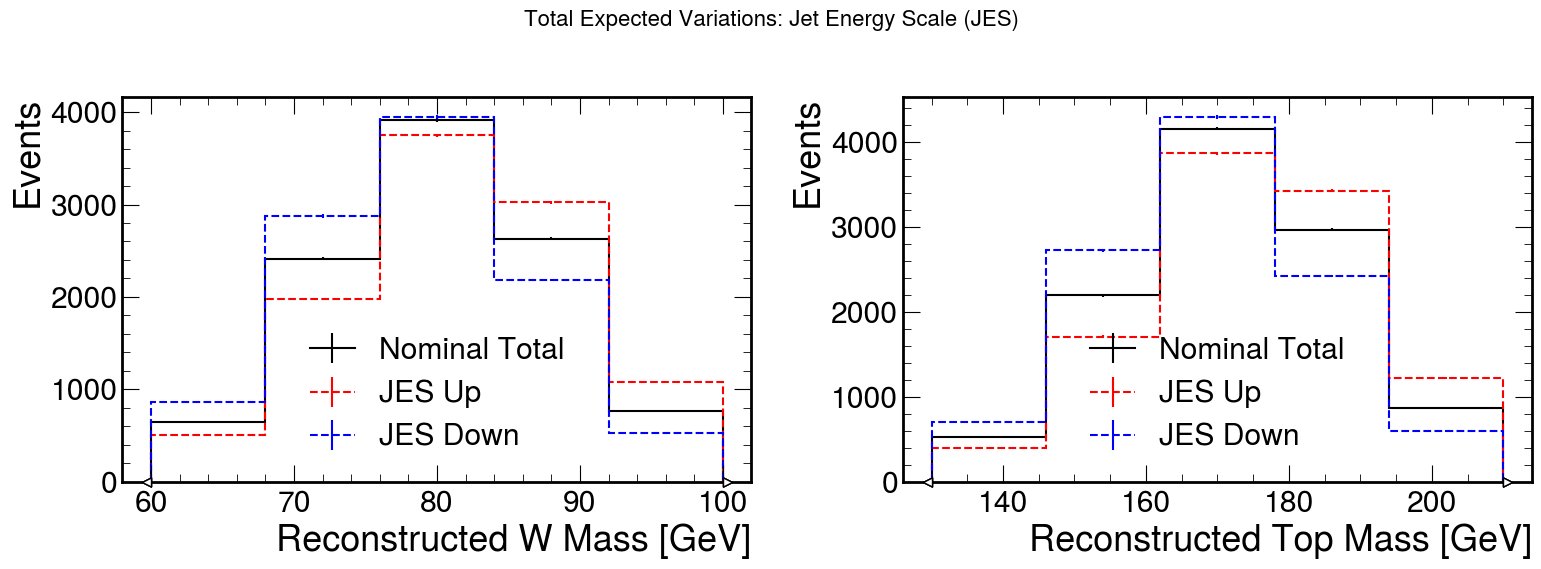

In [5]:
# Sum the nominal and varied templates
h_tot_nom = h_sig_nom + h_bkg_nom
h_tot_jes_up = h_sig_jes_up + h_bkg_jes_up
h_tot_jes_dn = h_sig_jes_dn + h_bkg_jes_dn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Total Expected Variations: Jet Energy Scale (JES)", fontsize=16)

# Reconstructed W Mass Axis
hep.histplot(h_tot_nom.project("m_W"), color='black', label='Nominal Total', ax=ax1)
hep.histplot(h_tot_jes_up.project("m_W"), color='red', linestyle='--', label='JES Up', ax=ax1)
hep.histplot(h_tot_jes_dn.project("m_W"), color='blue', linestyle='--', label='JES Down', ax=ax1)
ax1.set_xlabel("Reconstructed W Mass [GeV]")
ax1.set_ylabel("Events")
ax1.legend()

# Reconstructed Top Mass Axis
hep.histplot(h_tot_nom.project("m_top"), color='black', label='Nominal Total', ax=ax2)
hep.histplot(h_tot_jes_up.project("m_top"), color='red', linestyle='--', label='JES Up', ax=ax2)
hep.histplot(h_tot_jes_dn.project("m_top"), color='blue', linestyle='--', label='JES Down', ax=ax2)
ax2.set_xlabel("Reconstructed Top Mass [GeV]")
ax2.set_ylabel("Events")
ax2.legend()

plt.tight_layout()
plt.show()

## Writing the tensor

The channel is now a 2D histogram. The top mass dependence is encoded as an unconstrained shape variation (`top_mass_shift`). The JES is added as a standard shape systematic.

In [6]:
writer = tensorwriter.TensorWriter()

writer.add_channel(h_data.axes, "mass_region_2d")
writer.add_data(h_data, "mass_region_2d")

writer.add_process(h_sig_nom, "signal", "mass_region_2d", signal=True)
writer.add_process(h_bkg_nom, "background", "mass_region_2d", signal=False)

writer.add_norm_systematic("bkg_norm", "background", "mass_region_2d", 1.10)

writer.add_systematic(
    [h_sig_mtop_up, h_sig_mtop_dn], 
    "top_mass_shift", 
    "signal", 
    "mass_region_2d", 
    symmetrize="average", 
    constrained=False,  
    noi=True            
)

writer.add_systematic(
    [h_sig_jes_up, h_sig_jes_dn], 
    "jes", 
    "signal", 
    "mass_region_2d", 
    symmetrize="average", 
    constrained=True
)

writer.add_systematic(
    [h_bkg_jes_up, h_bkg_jes_dn], 
    "jes", 
    "background", 
    "mass_region_2d", 
    symmetrize="average", 
    constrained=True
)

out_hdf5 = f"{outdir}/top_mass_jes_tensor.hdf5"
writer.write(outfolder=outdir, outfilename="top_mass_jes_tensor")
print(f"Tensor written to {out_hdf5}")

Tensor written to results/top_mass/top_mass_jes_tensor.hdf5


## Input data diagnostics
First, let us look if the input data looks healthy

In [7]:
!debug_inputdata.py {outdir}/top_mass_jes_tensor.hdf5 -v 4

2026-03-19 15:10:47.774399: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 15:10:47.856949: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 15:10:49.323755: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
INFO:debug_inputdata.py: Debugging input file: results/top_mass/top_mass_jes_tensor.hdf5
2026-03-19 15:10:50.193168: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
mass_region_2d {'axes': [Regular(5, 60, 100, name='m_W', label='Reconstructed W Mass [GeV]'), Regular(5, 130, 210, name=

2026-03-19 15:10:52.375410: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 15:10:52.424994: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 15:10:53.719548: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 15:10:54.246458: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
mass_region_2d {'axes': [Regular(5, 60, 100, name='m_W', label='Reconstructed W Mass [GeV]'), Regular(5, 130, 210, name='m_top', label='Reconstructed Top Mass [GeV]')], 'masked': False, 'flow': False, 'start':

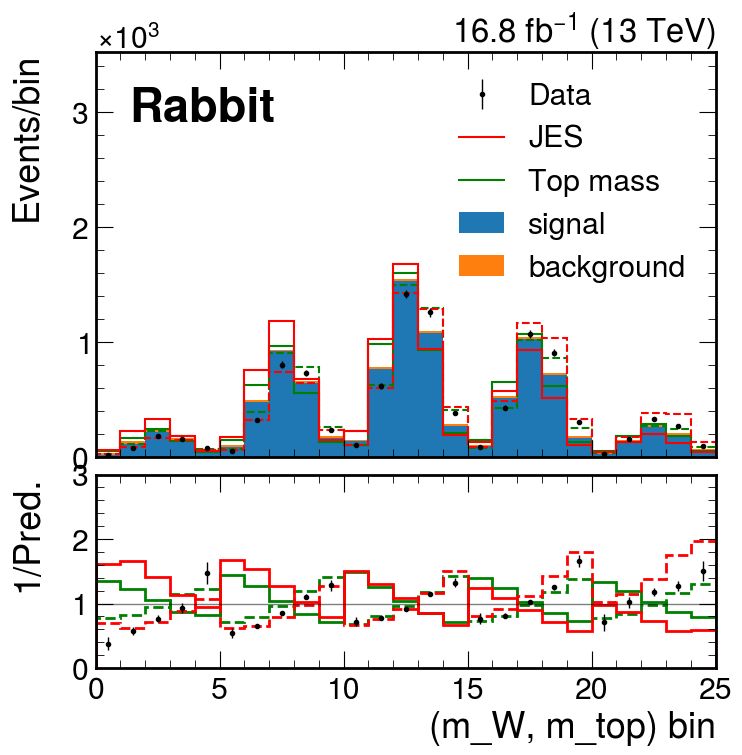

In [8]:
!rabbit_plot_inputdata.py {outdir}/top_mass_jes_tensor.hdf5 -o {outdir} --legCols 1 --yscale 2 --rrange 0.0 3.0 \
--varName top_mass_shift jes --varLabel 'Top mass' 'JES' --varColor green red

#display(Image(filename=f'{outdir}/hist_stack_m_W_mass_region_2d.png'))
#display(Image(filename=f'{outdir}/hist_stack_m_top_mass_region_2d.png'))
display(Image(filename=f'{outdir}/hist_stack_m_W_m_top_mass_region_2d.png'))

## Running the fit

We will scan the `top_mass_shift` parameter.

In [9]:
!rabbit_fit.py {outdir}/top_mass_jes_tensor.hdf5 -t 0 -o {outdir} --scan top_mass_shift --unblind \
--saveHists --saveHistsPerProcess --computeHistErrors --computeVariations --doImpacts --globalImpacts

2026-03-19 15:10:58.861765: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 15:10:58.910056: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-19 15:11:00.322644: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-19 15:11:02.601775: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
mass_region_2d {'axes': [Regular(5, 60, 100, name='m_W', label='Reconstructed W Mass [GeV]'), Regular(5, 130, 210, name='m_top', label='Reconstructed Top Mass [GeV]')], 'masked': False, 'flow': False, 'start':

## Fit Diagnostics
### Prefit & postfit plots

INFO:rabbit_plot_hists.py: Make plot for BaseMapping in channel mass_region_2d
INFO:plot_tools.py: Wrote file(s) results/top_mass//prefit_m_W_m_top_mass_region_2d_BaseMapping.pdf(.png)
INFO:plot_tools.py: Wrote file(s) results/top_mass//prefit_m_W_m_top_mass_region_2d_BaseMapping.pdf(.png)
INFO:rabbit_plot_hists.py: Make plot for BaseMapping in channel mass_region_2d
INFO:plot_tools.py: Wrote file(s) results/top_mass//postfit_m_W_m_top_mass_region_2d_BaseMapping.pdf(.png)
INFO:plot_tools.py: Wrote file(s) results/top_mass//postfit_m_W_m_top_mass_region_2d_BaseMapping.pdf(.png)


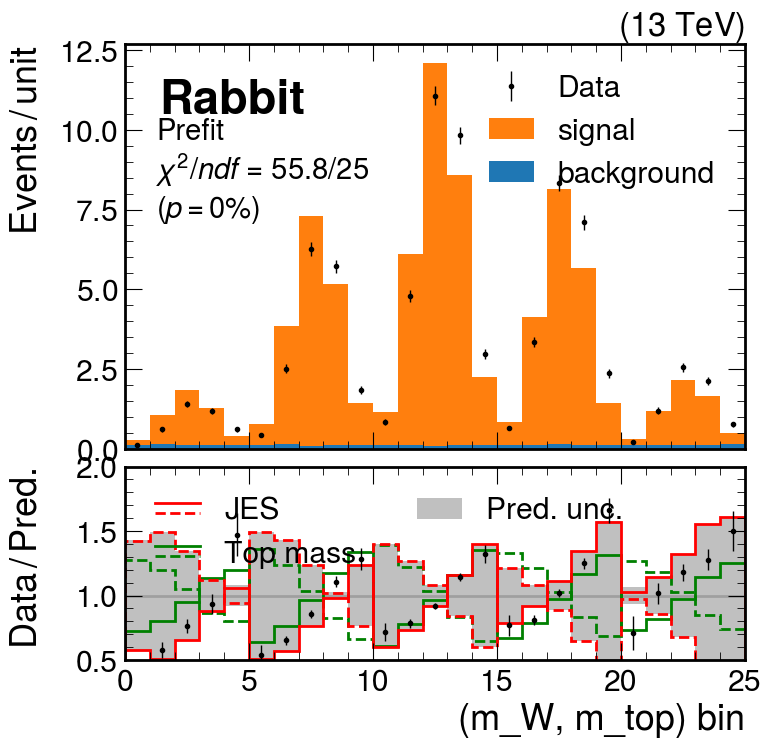

In [10]:
!rabbit_plot_hists.py {outdir}/fitresults.hdf5 -m BaseMapping -o {outdir} \
 --legCols 1 --rrange 0.5 2.0 --extraTextLoc 0.05 0.82 \
--varName top_mass_shift jes --varLabel 'Top mass' 'JES' --varColor green red --prefit

!rabbit_plot_hists.py {outdir}/fitresults.hdf5 -m BaseMapping -o {outdir} \
--legCols 1 --rrange 0.5 2.0 --extraTextLoc 0.05 0.82 \
--varName top_mass_shift jes --varLabel 'Top mass' 'JES' --varColor green red

display(Image(filename=f'{outdir}/prefit_m_W_m_top_mass_region_2d_BaseMapping.png'))

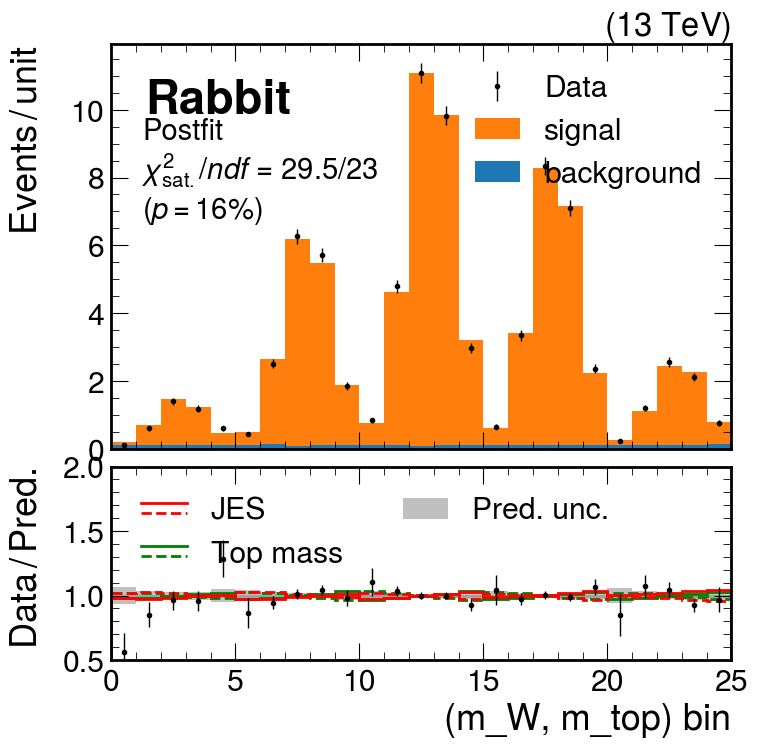

In [11]:
display(Image(filename=f'{outdir}/postfit_m_W_m_top_mass_region_2d_BaseMapping.png'))

## Interpreting the result

The pulls and constraints. Notice how
- the top mass pull is around 0.5, meaning we retrieve the injected value of 174 GeV ($172.5+0.5 \sigma$ pull)
- the JES is constrained to its injected value of +1% (+0.5 pull because $1\sigma$ is 2%).

In [12]:
!rabbit_print_pulls_and_constraints.py {outdir}/fitresults.hdf5

   Parameter                        pull +/- constraint (pull prefit +/- constraint prefit)
   ----------------------------------------------------------------------------------------------------
   signal                         0.98628 +/-    0.00564 (        1.0 +/-               0.0)
   top_mass_shift                 0.52965 +/-    0.09153 (        0.0 +/-               0.0)
   bkg_norm                       -0.74993 +/-    0.88269 (        0.0 +/-               1.0)
   jes                            0.50093 +/-    0.05954 (        0.0 +/-               1.0)


## Plotting the likelihood scan

INFO:plot_tools.py: Wrote file(s) results/top_mass//nll_scan_top_mass_shift.pdf(.png)
INFO:plot_tools.py: Wrote file(s) results/top_mass//nll_scan_top_mass_shift.pdf(.png)


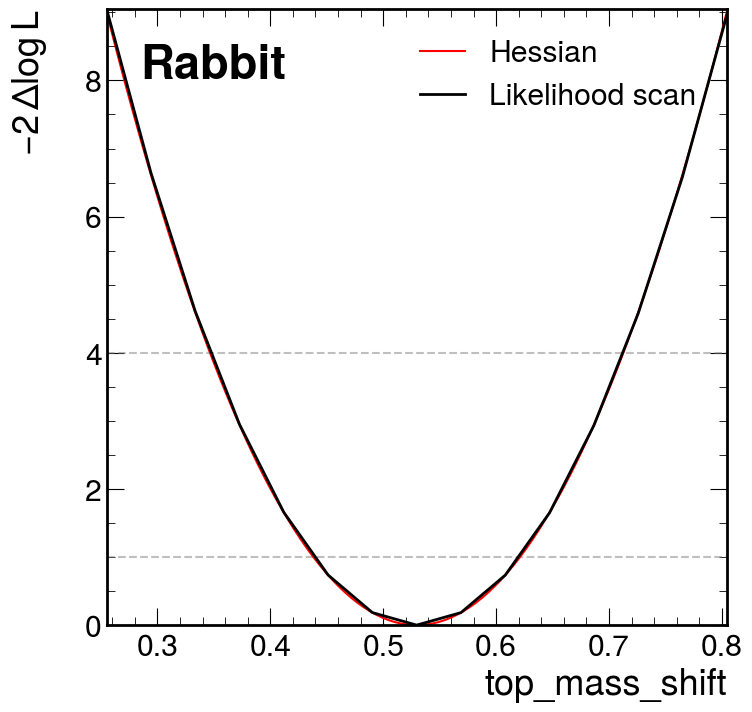

In [13]:
!rabbit_plot_likelihood_scan.py {outdir}/fitresults.hdf5 --param top_mass_shift -o {outdir}

Image(filename=f'{outdir}/nll_scan_top_mass_shift.png') 

/home/mseidel/Tools/rabbit/env/lib64/python3.12/site-packages/hist/basehist.py:549: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))
Write output file results/top_mass/nll_scan2D_top_mass_shift_jes.png
Write output file results/top_mass/nll_scan2D_top_mass_shift_jes.pdf


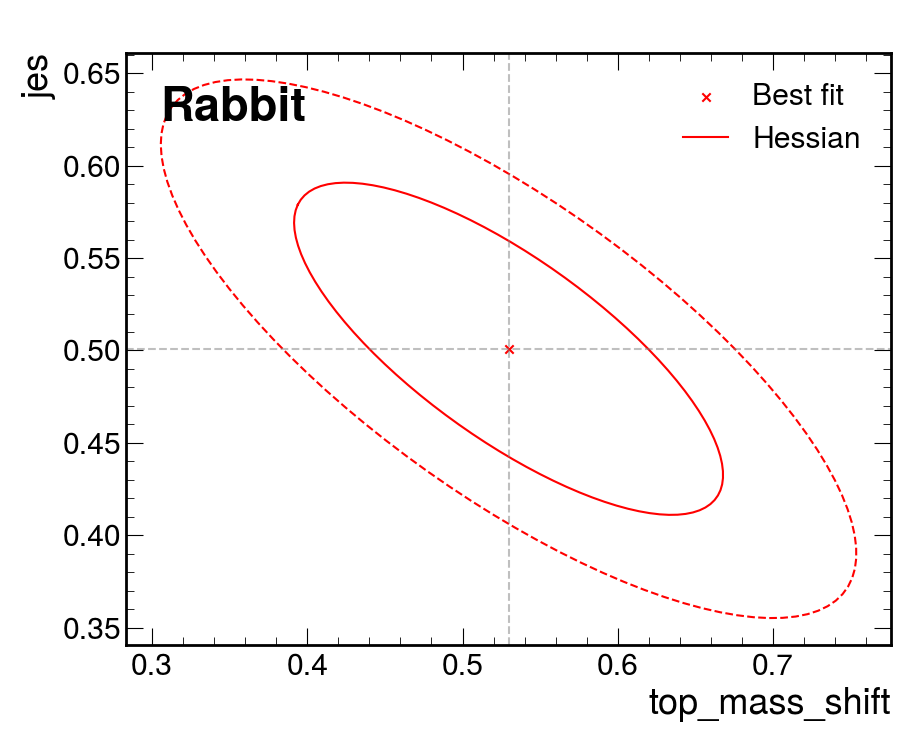

In [14]:
!rabbit_plot_likelihood_scan2D.py {outdir}/fitresults.hdf5 --param top_mass_shift jes -o {outdir}

display(Image(filename=f'{outdir}/nll_scan2D_top_mass_shift_jes.png'))

### Pulls and impacts

In [15]:
!rabbit_plot_pulls_and_impacts.py {outdir}/fitresults.hdf5 -o {outdir} --scaleImpacts 3

IFrame(src=f'{outdir}/pulls_and_impacts_top_mass_shift.html', width='100%', height=300)

Now at signal
Write output file results/top_mass/pulls_and_impacts_signal.html
Write output file results/top_mass/impacts_grouped_signal.html
Now at top_mass_shift
Write output file results/top_mass/pulls_and_impacts_top_mass_shift.html
Write output file results/top_mass/impacts_grouped_top_mass_shift.html


In [16]:
IFrame(src=f'{outdir}/impacts_grouped_top_mass_shift.html', width='100%', height=300)

### Correlation matrix

INFO:plot_tools.py: Wrote file(s) results/top_mass//hist_corr_postfit_parms_x_parms_y_params.pdf(.png)
INFO:plot_tools.py: Wrote file(s) results/top_mass//hist_corr_postfit_parms_x_parms_y_params.pdf(.png)


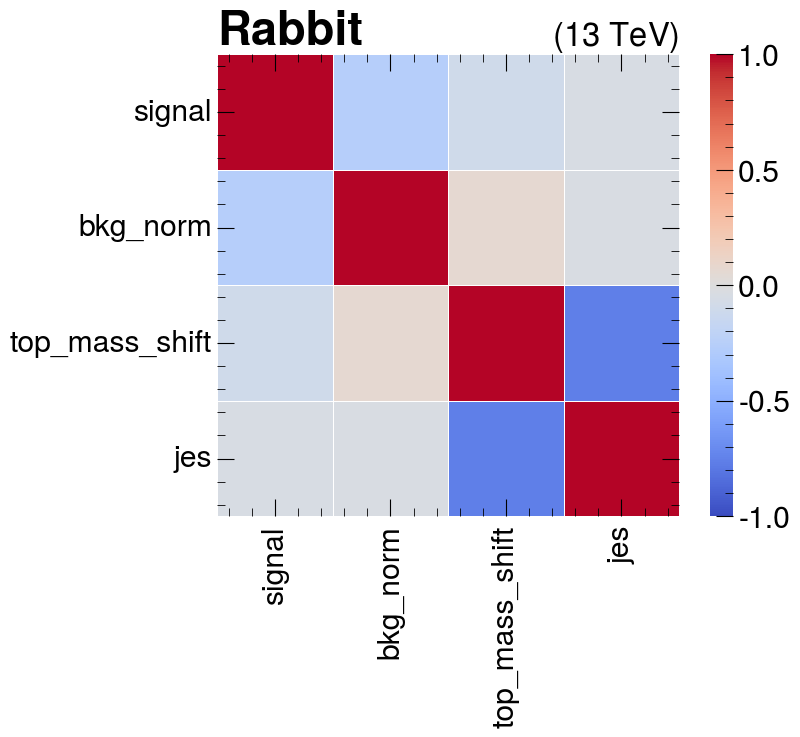

In [17]:
!rabbit_plot_cov.py {outdir}/fitresults.hdf5 \
--params signal bkg_norm top_mass_shift jes --correlation -o {outdir} --titlePos 0

display(Image(filename=f'{outdir}/hist_corr_postfit_parms_x_parms_y_params.png'))